# ECBM E4070/6070 2026 Project 1 Handout

_Copyright 2024_ Shashwat Shukla, Bruce Yi Bu, and Aurel A. Lazar

### NAME and UNI

### Miscellaneous (attention)
* please remember to include your name in the corresponding field at the start of this notebook, otherwize an automatic 0 grade will be received for any missing member
* please submit one copy per team
* please clearly present your solutions and answers with proper use of plots, markdown and comments
* please start the project as soon as possible, submission deadlines are strictly followed and late submissions after we posted the solution (ususlly on the same day as the deadline) will receive automatic 0
* please email both TAs at least 48hrs ahead of deadline if you cannot submit an assignment on time (due to exam schedules or  overwhelming deadlines, etc), we are flexible as long as we are informed
* please post your questions on Ed Discussions, and attend the office hours (every Thursday evening); **more on Ed**:
    * while discussing on Ed, please make good use of the reply and comment features inside threads to avoid cluttering with multiple threads regarding the same question from the same user
    * please refrain from asking questions or posting threads that would explicitly share the right answer with everyone
    * only post code snipets when you have narrowed down the issue to that particular section and only share ploted results only when you have good reason to suspect their correctness
    * once you finish debugging your code by the end of a thread, please avoid languages such as "is this correct now?" since we aren't really allowed to explicitly say yes when they are; be confident in your hardwork
* please restart your kernel and run all cells and save before you submit, to ensure the submission does not have any bugs or cells out of order
   * any code that runs into bugs will not be graded.

### Setup

In [ ]:
# import libraries #
import math
import numpy as np
np.random.seed(0)
from scipy.ndimage import convolve
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# specify simulation parameters #
dt = 5e-4  # timestep (sec)
T = 0.2  # total simulation time (sec)
t = np.arange(0, T, dt)  # timesteps (sec)
N = len(t)  # number of timesteps
W = 500  # screen width (pixels)
H = 250  # screen height (pixels)

In [ ]:
# define static random background
background = np.random.random((W, H))

# specify moving rectangular dark objects
# ! specify speed and direction separately ! #
rect1 = {
    "dims": np.array([5, 5], dtype=int),  # rectangle width, height (pixels)
    "p0": np.array([25, 25], dtype=int),  # initial x,y position (pixels)
    "v": np.array([400, 400], dtype=int),  # x,y velocity (pixels/sec)
}
objects = [rect1]  # collate objects

# simulate object motion trajectories
trajectories = [np.zeros((N, 2))] * len(objects)
for m, obj in enumerate(objects):
    trajectories[m][0] = obj["p0"]
for i in range(1, N):
    # translate each object, with periodic screen boundaries
    for m, obj in enumerate(objects):
        trajectories[m][i] = np.remainder(
            trajectories[m][i - 1] + dt * obj["v"], [W, H]
        )

# store ground truth object trajectory data
ground_truth = []
for m, obj in enumerate(objects):
    entry = {
        "dims": obj["dims"],
        "p": trajectories[m],
    }
    ground_truth.append(entry)

# create input frames
frames = []
for i in range(N):
    frame = np.copy(background)
    for gt in ground_truth:
        w, h = gt["dims"]
        px, py = gt["p"][i].astype(int)
        # draw within screen bounds
        frame[
            np.max([0, px]) : np.min([px + w, W]), np.max([0, py]) : np.min([py + h, H])
        ] = 0
    frames.append(frame)
frames = np.array(frames)

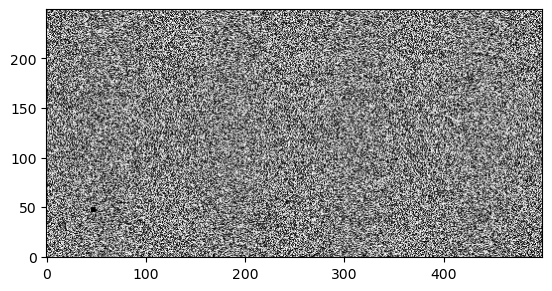

In [ ]:
plt.imshow(frames[100].T, origin="lower", cmap="gray")
plt.show()

In [ ]:
# parameters

# 1: ommatidium gaussian blur
σ1 = 1

# 4: bandpass gamma parameters
n1, τ1 = 2, 3
n2, τ2 = 6, 9

# 8, 9: lateral inhibition (spatial filter)
σ2 = 1.5
σ3 = 2 * σ2  # see Eq9

# 10, 11: lateral inhibition (temporal filter)
λ1 = 3
λ2 = 9
assert λ2 > λ1, "Eq11 requires λ2 > λ1."

# 20, 21: second-order lateral inhibition kernel
A = 1
B = 3

σ4 = 1.5
σ5 = 3
e = 1
ρ = 0

# 24: ESTMD correlation
n3, τ3 = 5, 25

In [ ]:
# helpers


# causal temporal convolution along axis 0, arr: (N, W, H)
def temporal_conv(arr, kernel):
    k3d = kernel[:, np.newaxis, np.newaxis]
    return fftconvolve(arr, k3d, mode="full")[: len(arr)]


# spatial convolution applied to each frame, arr: (N, W, H)
def spatial_conv_frames(frames, kernel_2d):
    # return np.array(
    #     [convolve2d(frame, kernel_2d, mode="same", boundary="wrap") for frame in frames]
    # )

    # more efficient 2d conv implementation:
    #
    # Reshape kernel to (1, K, K) so it slides across H and W
    # but only covers 1 frame at a time in the T dimension.
    kernel_3d = kernel_2d[np.newaxis, :, :]
    return convolve(frames, kernel_3d, mode="wrap")

### Retina

In [ ]:
# define retinal blur filter (2)


def make_gaussian_kernel(sigmas, truncate=4.0):
    """
    Build a 2D Gaussian kernel (Eq. 2) from ≥1 sigma

    Kernel half-width = truncate * max(sigmas), rounded to nearest int.

    If sigmas is numerical or length 1, returns kernel instead of list.
    """
    sigmas = np.atleast_1d(sigmas)

    # Define the global radius based on the largest sigma
    max_sigma = np.max(sigmas)
    radius = int(truncate * max_sigma + 0.5)
    y, x = np.mgrid[-radius : radius + 1, -radius : radius + 1]

    kernels = []
    for s in sigmas:
        # Avoid division by zero if sigma is 0
        if s == 0:
            kernel = np.zeros_like(x)
            kernel[radius, radius] = 1.0  # Impulse response
        else:
            # Standard Gaussian formula: exp(-(x^2 + y^2) / (2 * σ^2))
            kernel = np.exp(-(x**2 + y**2) / (2 * s**2))
            kernel /= kernel.sum()  # Normalize to sum to 1

        kernels.append(kernel)

    if len(kernels) == 1:
        kernels = kernels[0]

    return kernels


G_retina = make_gaussian_kernel(σ1)

In [ ]:
# compute ommatidium output (1)
P = spatial_conv_frames(frames, G_retina)

# P: (N, W, H)

### Lamina

In [ ]:
# define gamma function (5)
# Γ_{n,τ}(t) = (nt)^n * exp(-nt/τ) / ((n-1)! * τ^(n+1))
# normalized so sum * dt ≈ 1  (discrete approximation of unit integral)
def gamma_kernel(n, tau_ms, dt):
    tau = tau_ms * 1e-3  # ms → s
    t = np.arange(dt, 10 * tau, dt)
    kernel = (
        (n * t) ** n * np.exp(-n * t / tau) / (math.factorial(n - 1) * tau ** (n + 1))
    )
    return kernel / kernel.sum()

In [ ]:
# define temporal derivative filter -- bandpass (4)
# H(t) = Γ_{n1,τ1}(t) - Γ_{n2,τ2}(t)
h_fast = gamma_kernel(n1, τ1, dt)
h_slow = gamma_kernel(n2, τ2, dt)

# pad to same length before subtracting
K = max(len(h_fast), len(h_slow))
h_fast_p = np.pad(h_fast, (0, K - len(h_fast)))
h_slow_p = np.pad(h_slow, (0, K - len(h_slow)))
h_BPF = h_fast_p - h_slow_p

In [ ]:
# compute LMC output (3)
# L(x,y,t) = P(x,y,t) ⊛_t H(t)
L = temporal_conv(P, h_BPF)

# L: (N, W, H)

In [ ]:
# temporal trace kernels (10 + 11)
# Eq 10: W_T^P(t) = (1/λ1) * exp(-t/λ1)
lam1 = λ1 * 1e-3  # ms → s
t_lam1 = np.arange(dt, 10 * lam1, dt)
W_T_P = (1 / lam1) * np.exp(-t_lam1 / lam1)
W_T_P /= W_T_P.sum()

# Eq 11: W_T^N(t) = (1/λ2) * exp(-t/λ2),  λ2 > λ1
lam2 = λ2 * 1e-3
t_lam2 = np.arange(dt, 10 * lam2, dt)
W_T_N = (1 / lam2) * np.exp(-t_lam2 / lam2)
W_T_N /= W_T_N.sum()

In [ ]:
# spatial on-center and off-surround kernels (8 + 9)
# DoG on pixel grid: σ3 = 2*σ2 (set in params)

# on-center Gaussian, off-surround Gaussian
G_on_s, G_off_s = make_gaussian_kernel([σ2, σ3])
DoG_s = G_on_s - G_off_s

# Eq 8: W_S^P = [DoG]_+  (positive part of difference of Gaussians)
W_S_P = np.maximum(DoG_s, 0)

# Eq 9: W_S^N = [DoG]_-  (negative part)
W_S_N = np.minimum(DoG_s, 0)

In [ ]:
# compute laterally inhibited LMC output, using space-time separable kernels
# W1(x,y,t) = W_S^P(x,y)*W_T^P(t) + W_S^N(x,y)*W_T^N(t)  (Eq 7)

# temporal filtering
T_P = temporal_conv(L, W_T_P)  # fast temporal trace of L
T_N = temporal_conv(L, W_T_N)  # slow temporal trace of L

# spatial filtering
ST_P = spatial_conv_frames(T_P, W_S_P)  # on-center spatial component
ST_N = spatial_conv_frames(T_N, W_S_N)  # off-surround spatial component

# collate LMC output
LI = ST_P + ST_N

### Medulla

In [ ]:
# compute celltype outputs
# - (Tm3, Tm2) : (18, 19)
# - (Mi1, Tm1) : (22, 23) -- temporally delayed

# ON/OFF decomposition via half-wave rectification
S_ON = np.maximum(LI, 0)
S_OFF = np.maximum(-1 * LI, 0)

# build 2nd-order lateral inhibition kernel W2 (Eq 20, 21)
G4, G5 = make_gaussian_kernel([σ4, σ5])

g = G4 - e * G5 - ρ  # Eq 21
W2 = A * np.maximum(g, 0) + B * np.minimum(g, 0)  # Eq 20

# temporal delay kernels (22+23 -- gamma)
# gamma delay with parameters n3, τ3 (used for both Mi1 and Tm1)
h_delay = gamma_kernel(n3, τ3, dt)

# ON and delayed ON signals (18, 22 -- Tm3 & Mi1)
S_Tm3 = np.maximum(spatial_conv_frames(S_ON, W2), 0)  # Eq 18
S_Mi1 = temporal_conv(S_Tm3, h_delay)  # Eq 22

# OFF and delayed OFF signals (19, 23 -- Tm2 & Tm1)
S_Tm2 = np.maximum(spatial_conv_frames(S_OFF, W2), 0)  # Eq 19
S_Tm1 = temporal_conv(S_Tm2, h_delay)  # Eq 23

## Lobula

In [ ]:
# implement correlate for ESTMD (24)
# D̃(x,y,t) = S̃_Tm3(x,y,t) × S̃_Tm1_D(n3,τ3)(x,y,t)
D_tilde = S_Tm3 * S_Tm1

### Evaluation

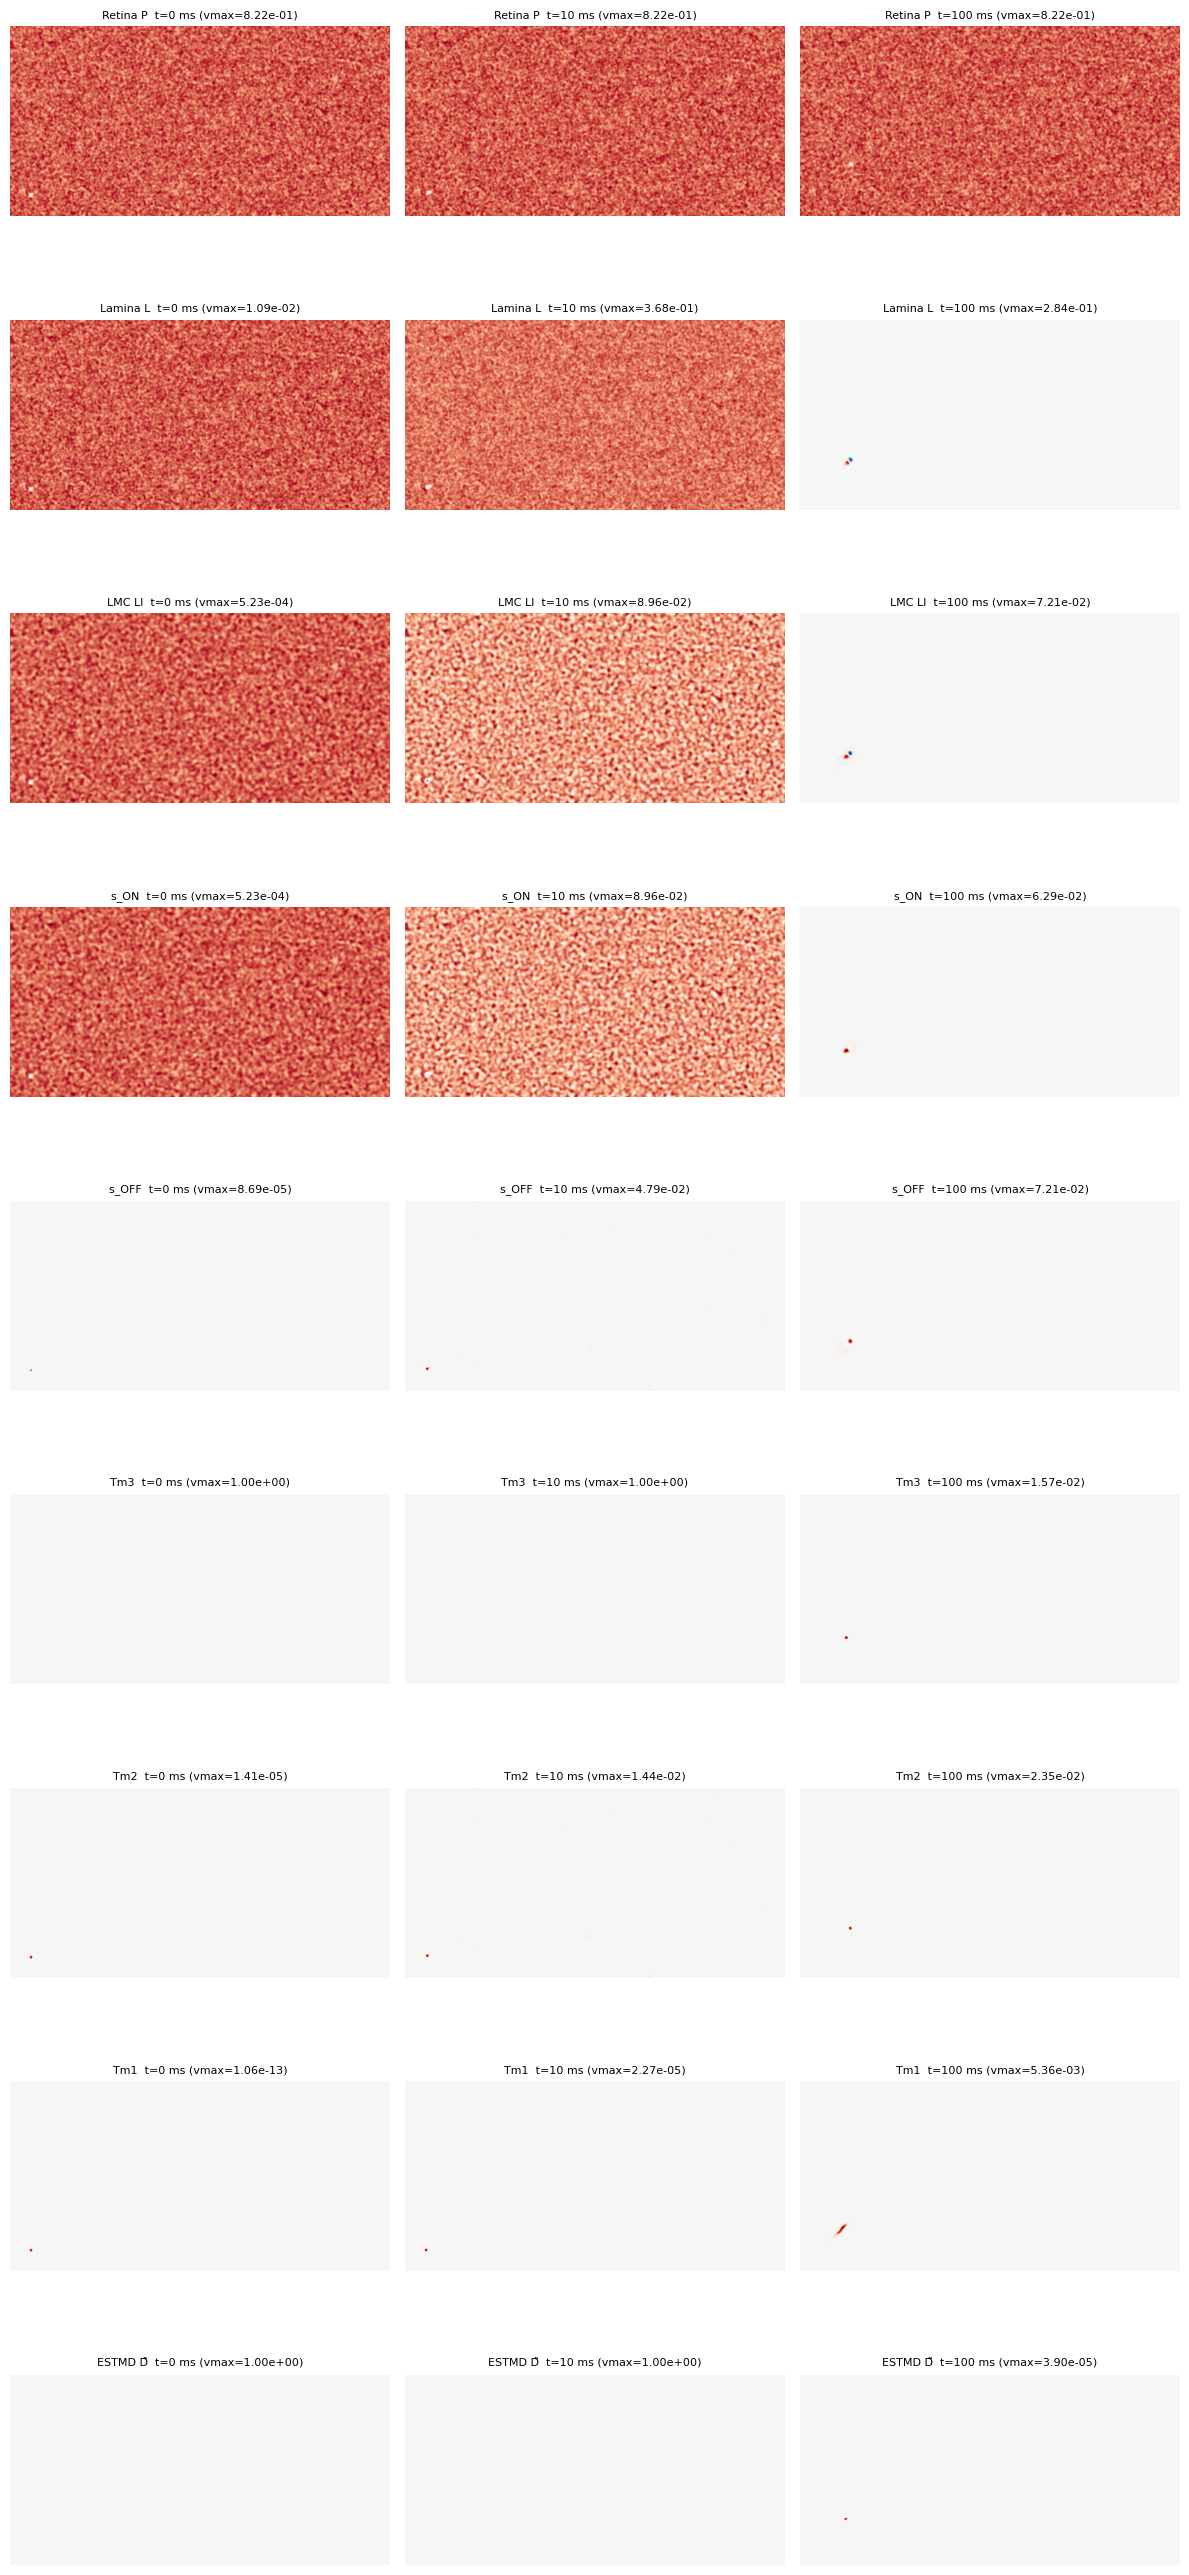

In [ ]:
# visualize layerwise activations #
# show each layer at t = 0 ms, 10 ms, 100 ms

layers = {
    "Retina P": P,
    "Lamina L": L,
    "LMC LI": LI,
    "s_ON": S_ON,
    "s_OFF": S_OFF,
    "Tm3": S_Tm3,
    "Tm2": S_Tm2,
    "Tm1": S_Tm1,
    "ESTMD D̃": D_tilde,
}
time_ms = [0, 10, 100]
t_idx = [int(t_ms * 1e-3 / dt) for t_ms in time_ms]

fig, axes = plt.subplots(len(layers), len(time_ms), figsize=(12, 3 * len(layers)))
for row, (name, arr) in enumerate(layers.items()):
    for col, (idx, t_ms) in enumerate(zip(t_idx, time_ms)):
        ax = axes[row, col]
        frame = arr[idx].T
        vmax = np.abs(frame).max() or 1
        ax.imshow(frame, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"{name}  t={t_ms} ms (vmax={vmax:.2e})", fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# helper functions for parametric sweeps


def make_frames(v_vec, dims):
    """Generate input frames for a dark square target with given velocity and size.
    Reuses the fixed `background` array for fair comparison across sweep conditions."""
    v_vec = np.array(v_vec, dtype=int)
    dims = np.array(dims, dtype=int)
    traj = np.zeros((N, 2))
    traj[0] = rect1["p0"]
    for i in range(1, N):
        traj[i] = np.remainder(traj[i - 1] + dt * v_vec, [W, H])
    out = []
    for i in range(N):
        frame = np.copy(background)
        w, h = dims
        px, py = traj[i].astype(int)
        frame[max(0, px) : min(px + w, W), max(0, py) : min(py + h, H)] = 0
        out.append(frame)
    return np.array(out)


def ESTMD(frames):
    """Run full ESTMD pipeline on frames (N, W, H). Returns D_tilde (N, W, H).

    Uses kernels precomputed in earlier cells (G_retina, h_BPF, W_T_P/N, W_S_P/N, W2, h_delay).
    """
    # retina
    P_ = spatial_conv_frames(frames, G_retina)

    # lamina
    L_ = temporal_conv(P_, h_BPF)
    LI_ = spatial_conv_frames(temporal_conv(L_, W_T_P), W_S_P) + spatial_conv_frames(
        temporal_conv(L_, W_T_N), W_S_N
    )

    # medulla
    S_on_ = np.maximum(LI_, 0)
    S_off_ = np.maximum(-1 * LI_, 0)

    S_Tm3_ = np.maximum(spatial_conv_frames(S_on_, W2), 0)
    S_Tm2_ = np.maximum(spatial_conv_frames(S_off_, W2), 0)
    S_Tm1_ = temporal_conv(S_Tm2_, h_delay)

    # ESTMD
    return S_Tm3_ * S_Tm1_

In [ ]:
# preallocate dicts for experiments

S_vel = {}
S_wid = {}

  v=[20,20] → S=4.570e-14(already computed)
  v=[50,50] → S=9.424e-09(already computed)
  v=[100,100] → S=2.650e-05(already computed)
  v=[200,200] → S=1.464e-05(already computed)
  v=[400,400] → S=9.995e-06(already computed)
  v=[600,600] → S=1.202e-10(already computed)
  v=[900,900] → S=4.516e-11(already computed)
  v=[1200,1200] → S=2.088e-11(already computed)


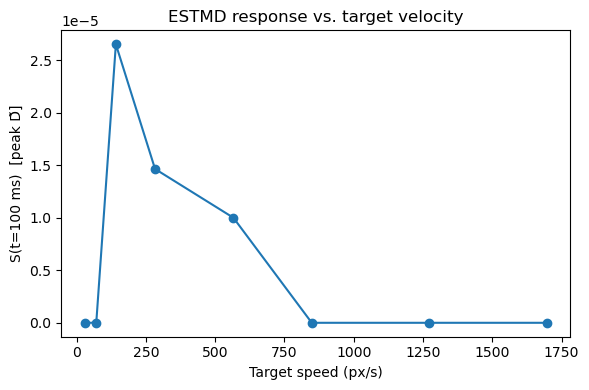

In [ ]:
# S(t=100ms) vs velocity
# hold dims=[10,10], vary speed s at 45° (v=[s,s] matches original convention)
idx_100 = int(0.1 / dt)  # frame index at t=100ms
speeds = [20, 50, 100, 200, 400, 600, 900, 1200]  # px/s per component

for s in speeds:
    if s in S_vel.keys():
        suffix = "(already computed)"
    else:
        suffix = ""
        D = ESTMD(make_frames([s, s], [10, 10]))
        S_vel[s] = D[idx_100].max()

    print(f"  v=[{s},{s}] → S={S_vel[s]:.3e}" + suffix)

fig, ax = plt.subplots(figsize=(6, 4))

x, y = zip(*sorted(S_vel.items()))
x = [_ * np.sqrt(2) for _ in x]  # true speed magnitude
ax.plot(x, y, "o-")

ax.set_xlabel("Target speed (px/s)")
ax.set_ylabel("S(t=100 ms)  [peak D̃]")
ax.set_title("ESTMD response vs. target velocity")
plt.tight_layout()
plt.show()

  dims=[2,2] → S=4.304e-07(already computed)
  dims=[4,4] → S=2.298e-06(already computed)
  dims=[6,6] → S=1.095e-06(already computed)
  dims=[8,8] → S=1.214e-07(already computed)
  dims=[10,10] → S=4.516e-11(already computed)
  dims=[12,12] → S=3.047e-11(already computed)


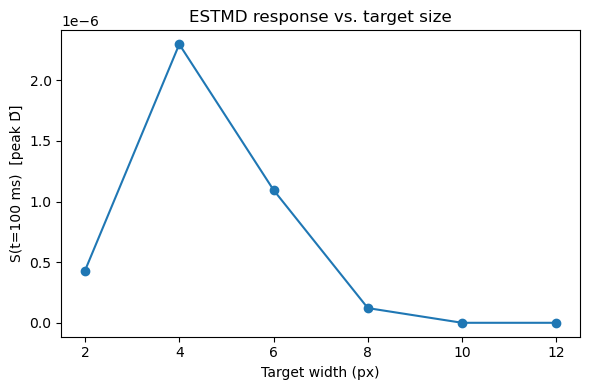

In [ ]:
# S(t=100ms) vs dot width
# hold v=[900,900], vary square target size
widths = [2, 4, 6, 8, 10, 12]  # px (square)

for w in widths:
    if w in S_wid.keys():
        suffix = "(already computed)"
    else:
        suffix = ""
        D = ESTMD(make_frames([900, 900], [w, w]))
        S_wid[w] = D[idx_100].max()

    print(f"  dims=[{w},{w}] → S={S_wid[w]:.3e}" + suffix)

fig, ax = plt.subplots(figsize=(6, 4))

x, y = zip(*sorted(S_wid.items()))
ax.plot(x, y, "o-")

ax.set_xlabel("Target width (px)")
ax.set_ylabel("S(t=100 ms)  [peak D̃]")
ax.set_title("ESTMD response vs. target size")
plt.tight_layout()
plt.show()